# Algoritmos de Inteligencia Artificial con Redes Neuronales Artificiales #
<img align="left" src="home.jpg" style="width: 400px"/>
<br/><br/>
<br/><br/>
<br/><br/>
<br/><br/>
<br/><br/>
<br/><br/>

"Estructura de los centros nerviosos de las aves" dibujo de Ramón y Cajal, obtenido de [wikipedia](https://en.wikipedia.org/wiki/Santiago_Ram%C3%B3n_y_Cajal#/media/File:CajalCerebellum.jpg)

---
### Taller impartido en el Instituto Tecnológico Superior del sur de Guanajuato en el 2018 ###

Únete a la conversación en el subredit [r/algoritmica](https://reddit.com/r/algoritmica)

---
### Cómo obtener los materiales del curso ###
1. Crea una cuenta en [github](https://github.com) 
2. Inicia sesión en [juliabox](https://v1.juliabox.com) usando tu cuenta de github
3. En la consola de juliabox escribe el siguiente comando:
```
git clone https://github.com/iranroman/algoritmica_ejercicios.git
```
4. (opcional) crea una cuenta en [reddit](https://reddit.com) y continúa la discusión fuera del aula

Así obtendrás una versión en linea del lenguaje de programación Julia y los ejercicios que estudiaremos en este taller. 



---

# Contenido del Día No. 1 #

## Parte 1.1: Características de Datos ##

Los objetos del mundo real pueden ser descritos por sus características. Existen un número infinito de características asociadas con un objeto específico. Sin embargo, unas de estas características resultan ser más importantes al diferenciar un objeto de otro. 

Por ejemplo, supongamos que nos interesa diferenciar tres tipos de flores por especie. Esto le interesó a [Ronald Fisher](https://en.wikipedia.org/wiki/Ronald_Fisher) en 1993. En un estudio científico, Fisher se propuso identificar las características más importantes que podrían diferenciar tres especies distintas de flores.
<a href="https://i.ytimg.com/vi/RSKhj2BZQBg/maxresdefault.jpg">
<img src="https://i.ytimg.com/vi/RSKhj2BZQBg/maxresdefault.jpg" style="width: 400px"/>
</a>    
Para diferenciar estas flores, Fisher usó la longitud y anchura de los pétalos y sépalos de estás tres especies.

Los datos que Fisher colectó se han convertido en una base de datos clásica para estudiar algoritmos de inteligencia artificial. Se encuentra disponible de forma gratuita en internet. 

El siguiente programa prepara los datos de Fisher para poder trabajar con ellos.

In [1]:
# instalamos un paquete de Julia para poder obtener los datos
Pkg.add("MAT") 
using MAT

# obtenemos los datos que necesitamos
iris = matread("iris.mat")
caracteristicas = iris["meas"]
especies = iris["species"];

INFO: Nothing to be done
INFO: METADATA is out-of-date — you may not have the latest version of MAT
INFO: Use `Pkg.update()` to get the latest versions of your packages


Aquí obtenemos los datos de 150 flores que Fisher midió. La variable `caracteristicas` es una matriz 150x4, cuyas ileras corresponden a las características (longitud de pétalo, anchura de pétalo, longitud de sépalo, y anchura de sépalo) de cada flor. La variable `especies` es un vector 150x1 que contiene los nombres de especies que corresponden a las ileras de la matriz `características`.

El siguiente código muestra como podemos visualizar la primera de las cuatro características. En la figura, cada color representa un tipo de flor.

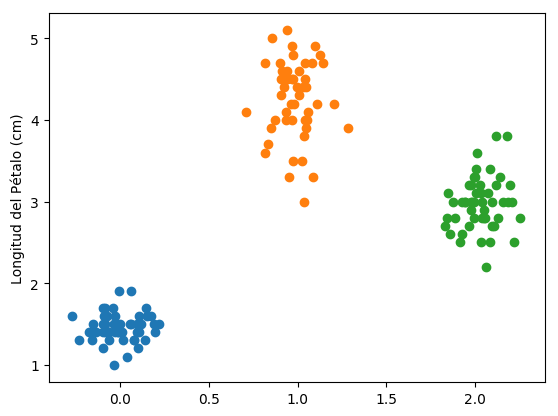

INFO: Nothing to be done
INFO: METADATA is out-of-date — you may not have the latest version of PyPlot
INFO: Use `Pkg.update()` to get the latest versions of your packages


PyObject <matplotlib.text.Text object at 0x7fb7a7588810>

In [2]:
# instalamos un paquete de Julia para poder visualizar los datos
Pkg.add("PyPlot")
using PyPlot

# graficamos la longitud de pétalo para el primer tipo de flores
scatter(0.1*randn(50,1),caracteristicas[1:50,1])
# agregamos la longitud de pétalo para el segundo tipo de flores
scatter(1+0.1*randn(50,1),caracteristicas[51:100,1])
# agregamos la longitud de pétalo para el tercer tipo de flores
scatter(2+0.1*randn(50,1),caracteristicas[101:150,4])
ylabel("Longitud del Pétalo (cm)")

En el siguiente espacio, trabaja con la persona junto a tí y grafiquen las cuatro características en cuatro figuras distintas. Determinen cuales son las dos características que mejor sirven para diferenciar las tres especies de flores.

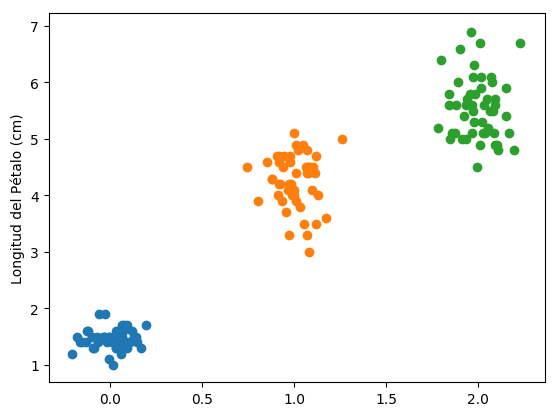

PyPlot.Figure(PyObject <matplotlib.figure.Figure object at 0x7fb7a7409a90>)

In [3]:
# graficamos la longitud de pétalo para el primer tipo de flores
figure(1)
scatter(0.1*randn(50,1),caracteristicas[1:50,1])
scatter(1+0.1*randn(50,1),caracteristicas[51:100,1])
scatter(2+0.1*randn(50,1),caracteristicas[101:150,1])
ylabel("Longitud del Pétalo (cm)")

# graficamos la anchura del pétalo
figure(2)
### tu código aquí ###

# graficamos la longitud del sépalo
figure(3)
### tu código aquí ###

# graficamos la anchura del sépalo
figure(4)
### tu código aquí ###

Al parecer, las dos características que mejor separan los tres tipos de flores fueron la _______ de _______ y la _______ de _______. La siguiente figura muestra como estas dos características diferencian los tres tipos de flores.

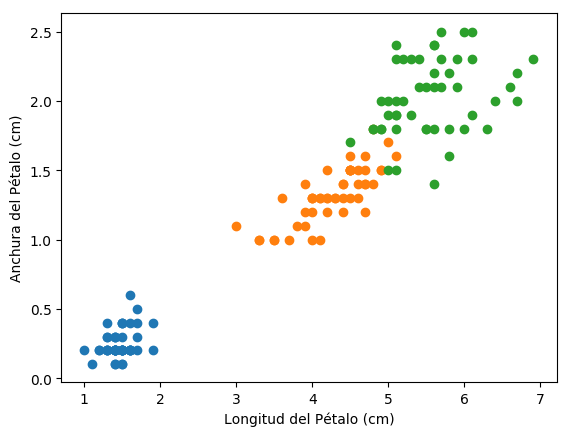

PyObject <matplotlib.text.Text object at 0x7fb7a73d69d0>

In [4]:
scatter(caracteristicas[1:50,1],caracteristicas[1:50,2])
scatter(caracteristicas[51:100,1],caracteristicas[51:100,2])
scatter(caracteristicas[101:150,1],caracteristicas[101:150,2])
xlabel("Longitud del Pétalo (cm)")
ylabel("Anchura del Pétalo (cm)")

Experimenta generando otras figuras donde grafiques otras características en los ejes x e y. Determina si alguna otra pareja de características sirve para diferenciar las tres especies de flores. Después procede a responder las siguientes preguntas con la persona sentada junto a tí.

Preguntas para reflexionar:

1. ¿Serán estas en realidad las mejores características para diferenciar estas especies de flores?
2. ¿Cuales son las mayores desventajas de usar estas características para diferenciar especies de flores?
3. ¿Qué otras características de flores podríamos utilizar para diferenciar distintas especies?
4. ¿Por qué dijimos al inicio que un objeto, en este caso un tipo de flor, tiene un número infinito de características?
5. Si salimos al campo y obtenemos medidas nuevas de una flor de cada especie que Fisher estudió, ¿serán nuestras medidas similares a las de Fisher? ¿Podrías estimar donde quedarían las medidas nuevas de flor de cada especie en la última figura que generaste?

## Parte 1.2: Clasificación de Datos ##

Usando una base de datos como la de Fisher podemos diseñar un método para determinar si las características de una flor pertenecen a uno de los tres grupos. Un método capáz de hacer esto es llamado un Algoritmo de Clasificación. 

Usando los datos de Fisher, ¿cómo podríamos diseñar un método para determinar si las características de una especie específica de flor?

Muchos algoritmos actuales para la clasificación de datos se enfocan en maximizar el producto interno entre dos vectores de la misma clase, donde uno de los vectores son las características de un objeto, y el otro vector son las características "promedio" de una clase específica.

Estudiemos esto con las dos características de las flores que midió Fisher que determinamos mejor sirven para separar distintas especies de flores. En la siguiente figura se observan estas dos características.

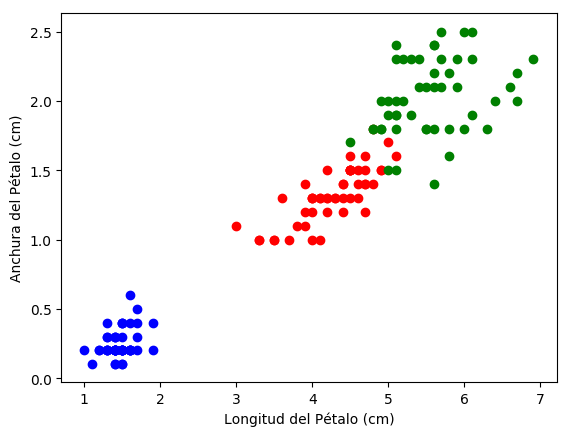

PyObject <matplotlib.text.Text object at 0x7fb7a28dcb10>

In [48]:
# graficamos las dos características que más sirven para diferenciar las especies de flores.
scatter(caracteristicas[1:50,1],caracteristicas[1:50,2], color="b")
scatter(caracteristicas[51:100,1],caracteristicas[51:100,2], color="r")
scatter(caracteristicas[101:150,1],caracteristicas[101:150,2], color="g")
xlabel("Longitud del Pétalo (cm)")
ylabel("Anchura del Pétalo (cm)")

Al trabajar con datos como estos, el primer paso es hacer que los datos estén centrados el rededor de cero. Esto se logra extrayendo las características promedio de todos los datos. El siguiente bloque muestra como hacer esto.

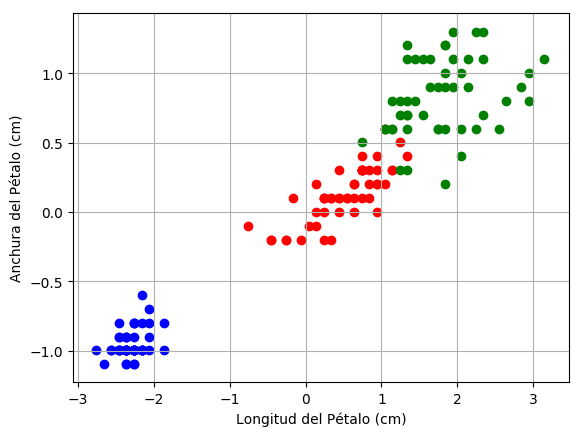

In [49]:
# generamos una variale con las dos características que nos interesan
x = [caracteristicas[:,1] caracteristicas[:,2]]

# obtenemos las características promedio
x_prom = mean(x,1)

# extraemos las caracteristicas promedio de nuestros datos
x = x - x_prom.*ones(150,2)

# graficamos nuevamente
scatter(x[1:50,1],x[1:50,2], color="b")
scatter(x[51:100,1],x[51:100,2], color="r")
scatter(x[101:150,1],x[101:150,2], color="g")
xlabel("Longitud del Pétalo (cm)")
ylabel("Anchura del Pétalo (cm)")
grid("on")

El siguiente paso consiste en encontrar el vector promedio para cada una de las expecies de plantas. El siguiente bloque muestra como se logra esto y también grafica los vectores con los datos.

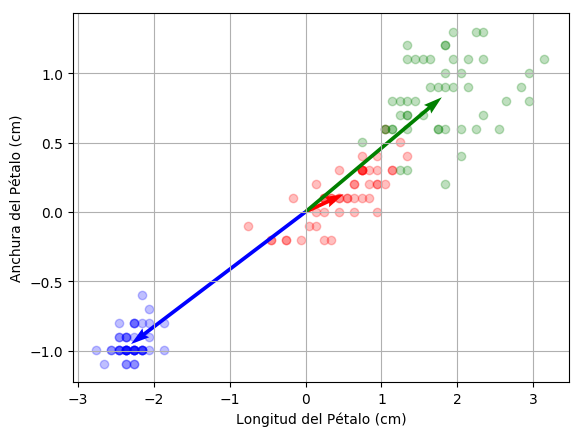

PyObject <matplotlib.quiver.Quiver object at 0x7fb7a28aecd0>

In [52]:
# graficamos los datos nuevamente
scatter(x[1:50,1],x[1:50,2],alpha=0.25, color="b")
scatter(x[51:100,1],x[51:100,2],alpha=0.25, color="r")
scatter(x[101:150,1],x[101:150,2],alpha=0.25, color="g")
xlabel("Longitud del Pétalo (cm)")
ylabel("Anchura del Pétalo (cm)")
grid("on")

# obtenemos los vectores con las características promedio para cada una de las clases de flores
prom_1 = mean(x[1:50,:],1)
prom_2 = mean(x[51:100,:],1)
prom_3 = mean(x[101:150,:],1)

# graficamos los vectores
quiver(prom_1[1,1],prom_1[1,2],angles="xy", scale_units="xy", scale=1, color="b")
quiver(prom_2[1,1],prom_2[1,2],angles="xy", scale_units="xy", scale=1, color="r")
quiver(prom_3[1,1],prom_3[1,2],angles="xy", scale_units="xy", scale=1, color="g")

Como podemos ver, estos "vectores promedio" están máximamente alineados con los datos de las clases de flores que les corresponden. El siguiente bloque de código toma una hilera de datos aleatoriamente, y calcula el producto interno de estos datos con los tres vectores promedio. 

In [81]:
# escogemos aleatoriamente una ilera en los datos
ilera_al = rand(1:150,1)

# extraemos los datos de esta ilera en una variable nueva
x_muestra = x[ilera_al,:]

# calculamos el producto interno de esta muestra con cada uno de los vectores promedio
prod_1 = x_muestra*prom_1'
prod_2 = x_muestra*prom_2'
prod_3 = x_muestra*prom_3'

# imprimimos los resultados
print("el producto interno del vector muestra con de los vectores promedio correspondientes a las especies de plantas son: \n")
print("\n setosa ", prod_1)
print("\n versicolor ", prod_2)
print("\n virginica ", prod_3)
print("\n\ny la especie correcta del vector muestra es: \n")
print("\n ", especies[ilera_al])

el producto interno del vector muestra con de los vectores promedio correspondientes a las especies de plantas son: 

 setosa [-4.57227]
 versicolor [0.950568]
 virginica [3.6217]

y la especie correcta del vector muestra es: 

 Any["virginica"]

Como podemos ver, el producto interno máximo es el que corresponde a la clase correcta de la especie de flor.

Preguntas para reflexionar en grupo:

1. ¿Cual sería el algoritmo a seguir si medimos una flor nueva y queremos determinar a que clase pertenece usando nuestro método?
2. ¿Son las características promedio de cada clase de flor el mejor método para clasificar los datos de Fisher?
3. ¿Qué problemas podríamos encontrar con nuestro método?

## Parte 1.3: Desarrollando un Algoritmo de Clasificación y Midiendo su Eficacia ##